In [30]:
%pip install geopandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import matplotlib.colors as mpc

In [29]:
sns.set_style('darkgrid')
sns.set_palette('husl')

In [30]:
svi_data = pd.read_csv('CIVE202_Project5_SVI_2022_US_county_Wiggins&Anciaux.csv', low_memory = True)
fema_data = pd.read_csv('FEMA_HurricanePaths.csv', low_memory = True)

In [32]:
states = gpd.read_file("cb_2024_us_state_500k.zip")

In [5]:
svi_data.columns

Index(['ST', 'STATE', 'ST_ABBR', 'STCNTY', 'COUNTY', 'FIPS', 'LOCATION',
       'AREA_SQMI', 'E_TOTPOP', 'M_TOTPOP',
       ...
       'EP_ASIAN', 'MP_ASIAN', 'EP_AIAN', 'MP_AIAN', 'EP_NHPI', 'MP_NHPI',
       'EP_TWOMORE', 'MP_TWOMORE', 'EP_OTHERRACE', 'MP_OTHERRACE'],
      dtype='object', length=158)

In [6]:
tx = svi_data[svi_data['STATE'] == 'Texas']
la = svi_data[svi_data['STATE'] == 'Louisiana']
ms = svi_data[svi_data['STATE'] == 'Mississippi']
al = svi_data[svi_data['STATE'] == 'Alabama']
ga = svi_data[svi_data['STATE'] == 'Georgia']
fl = svi_data[svi_data['STATE'] == 'Florida']

In [7]:
fema_data

,OBJECTID,SID,BASIN,SUBBASIN,NAME,NATURE,LAT,LON,USA_WIND,USA_PRES,year,month,day,Hurricane__Date
0,478408,1990177N14257,EP,MM,ELIDA,TS,20.0,-114.0,68,991,1990,6,29,6/29/1990 0:00
1,478685,1990191N10266,EP,MM,GENEVIEVE,TS,20.0,-116.3,85,973,1990,7,15,7/15/1990 0:00
2,479535,1990216N13281,NaN,NaN,DIANA,TS,20.0,-89.4,45,1000,1990,8,6,8/6/1990 0:00
3,481100,1990253N12248,EP,MM,NORBERT,TS,20.0,-116.2,43,1001,1990,9,13,9/13/1990 0:00
4,486526,1991220N13258,EP,MM,HILDA,TS,20.0,-114.3,55,992,1991,8,11,8/11/1991 0:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10660,592226,2006237N13298,NaN,NaN,ERNESTO,ET,39.9,-76.7,35,1012,2006,9,3,9/3/2006 0:00
10661,627461,2012296N14283,NaN,NaN,SANDY,ET,39.9,-76.2,55,960,2012,10,30,10/30/2012 0:00
10662,660465,2018146N19273,NaN,NaN,ALBERTO,TS,39.9,-87.0,30,998,2018,5,30,5/30/2018 0:00
10663,683303,2021222N14301,NaN,NaN,FRED,DS,39.9,-80.4,20,1012,2021,8,18,8/18/2021 0:00


In [8]:
fema_data['long_bins'] = pd.cut(fema_data['LON'], bins = range(-120, 70, 5))

binned_data = fema_data.groupby('long_bins', observed = True)['USA_WIND'].mean()                                

Text(0.5, 1.0, 'Average Wind Speed by Longitude')

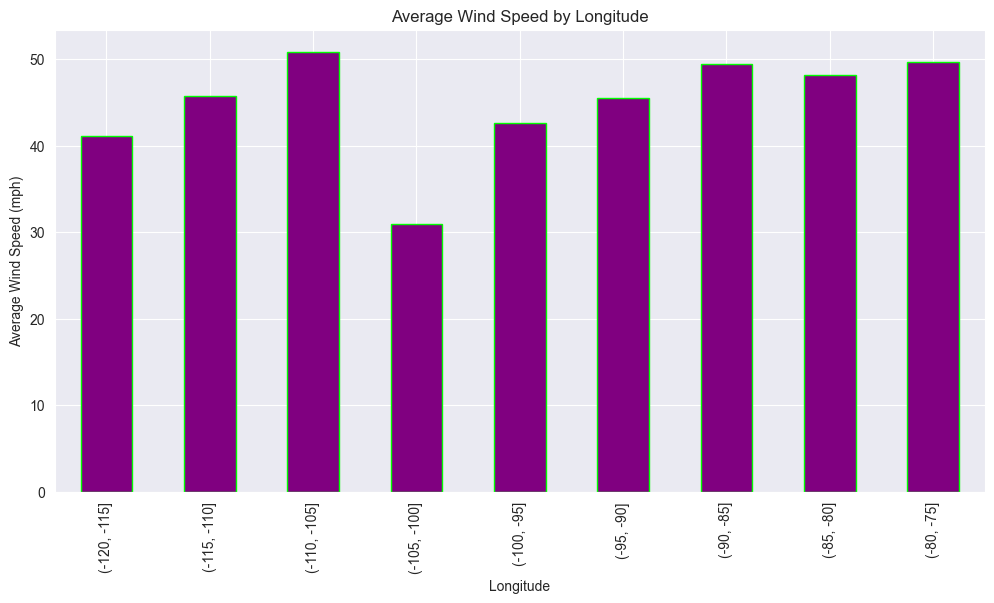

In [9]:
plt.figure(figsize = (12,6))
binned_data.plot(kind = 'bar', color = 'purple', edgecolor = 'lime')
plt.xlabel('Longitude')
plt.ylabel('Average Wind Speed (mph)')
plt.title('Average Wind Speed by Longitude')


In [10]:
fema_data

,OBJECTID,SID,BASIN,SUBBASIN,NAME,NATURE,LAT,LON,USA_WIND,USA_PRES,year,month,day,Hurricane__Date,long_bins
0,478408,1990177N14257,EP,MM,ELIDA,TS,20.0,-114.0,68,991,1990,6,29,6/29/1990 0:00,"(-115, -110]"
1,478685,1990191N10266,EP,MM,GENEVIEVE,TS,20.0,-116.3,85,973,1990,7,15,7/15/1990 0:00,"(-120, -115]"
2,479535,1990216N13281,NaN,NaN,DIANA,TS,20.0,-89.4,45,1000,1990,8,6,8/6/1990 0:00,"(-90, -85]"
3,481100,1990253N12248,EP,MM,NORBERT,TS,20.0,-116.2,43,1001,1990,9,13,9/13/1990 0:00,"(-120, -115]"
4,486526,1991220N13258,EP,MM,HILDA,TS,20.0,-114.3,55,992,1991,8,11,8/11/1991 0:00,"(-115, -110]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10660,592226,2006237N13298,NaN,NaN,ERNESTO,ET,39.9,-76.7,35,1012,2006,9,3,9/3/2006 0:00,"(-80, -75]"
10661,627461,2012296N14283,NaN,NaN,SANDY,ET,39.9,-76.2,55,960,2012,10,30,10/30/2012 0:00,"(-80, -75]"
10662,660465,2018146N19273,NaN,NaN,ALBERTO,TS,39.9,-87.0,30,998,2018,5,30,5/30/2018 0:00,"(-90, -85]"
10663,683303,2021222N14301,NaN,NaN,FRED,DS,39.9,-80.4,20,1012,2021,8,18,8/18/2021 0:00,"(-85, -80]"


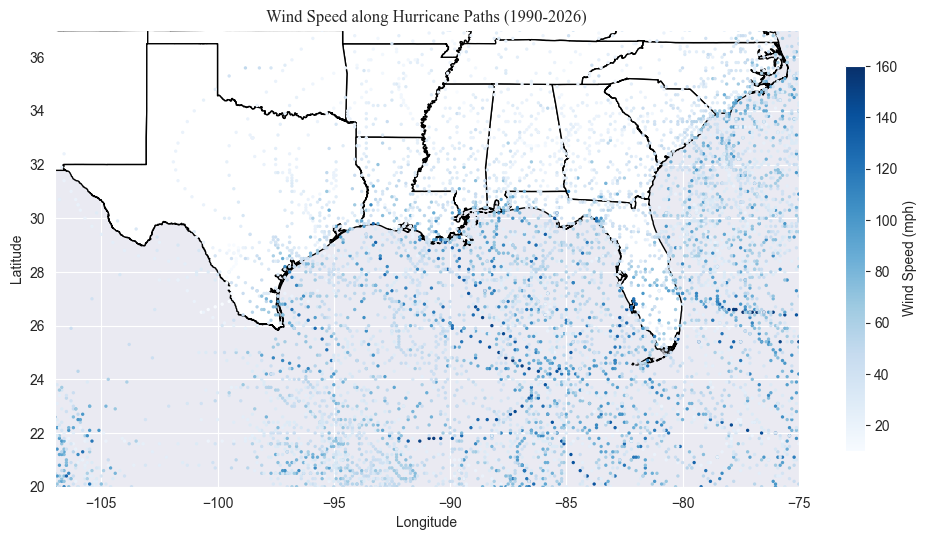

In [12]:
points = gpd.GeoDataFrame(fema_data, geometry = gpd.points_from_xy(fema_data['LON'], fema_data['LAT']), crs = 'NAD83')
points = points.to_crs(states.crs)
joined = gpd.sjoin(points, states, how = 'left', predicate = 'within')
fig, ax = plt.subplots(figsize=(12, 20))


states.plot(ax=ax, color='white', edgecolor='black')

# Plot the joined points, colored by a specific attribute from the CSV
joined.plot(ax=ax, column='USA_WIND', cmap='Blues', markersize=2, legend=True, legend_kwds={'shrink': 0.25, 'label': 'Wind Speed (mph)'})

ax.set_xlim([-107, -75])  
ax.set_ylim([20, 37])

plt.title('Wind Speed along Hurricane Paths (1990-2026)', fontname = 'Times New Roman')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()

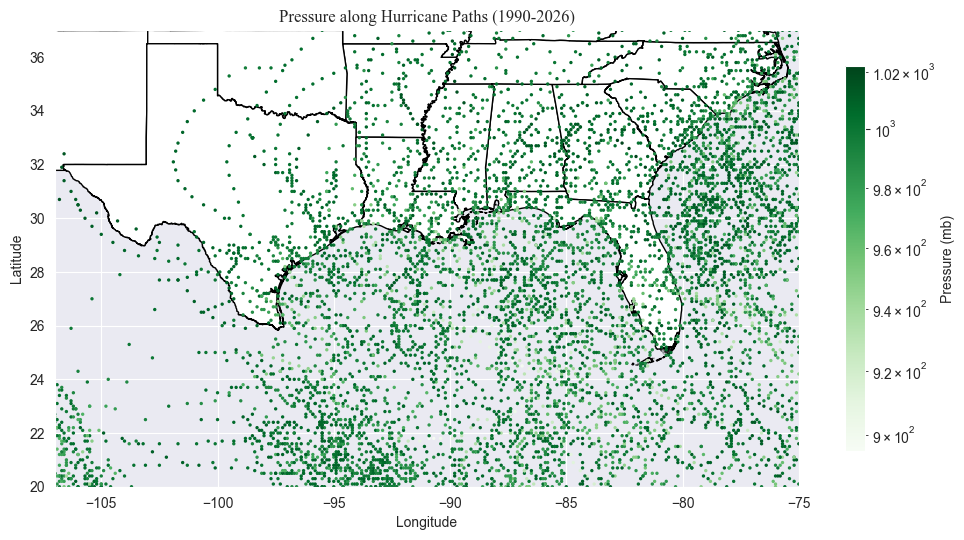

In [14]:
fig, ax = plt.subplots(figsize=(12, 20))


states.plot(ax=ax, color='white', edgecolor='black')

# Plot the joined points, colored by a specific attribute from the CSV
joined.plot(ax=ax, column='USA_PRES', cmap='Greens', markersize=2, legend=True, legend_kwds={'shrink': 0.25, 'label' : 'Pressure (mb)'}, norm = mpc.LogNorm())

ax.set_xlim([-107, -75])  
ax.set_ylim([20, 37])

plt.title('Pressure along Hurricane Paths (1990-2026)', fontname = 'Times New Roman')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()

In [15]:
svi_data

,ST,STATE,ST_ABBR,STCNTY,COUNTY,FIPS,LOCATION,AREA_SQMI,E_TOTPOP,M_TOTPOP,...,EP_ASIAN,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE
0,1,Alabama,AL,1001,Autauga County,1001,"Autauga County, Alabama",594.454786,58761,0,...,1.1,0.4,0.1,0.1,0.0,0.1,3.3,1.0,0.2,0.3
1,1,Alabama,AL,1003,Baldwin County,1003,"Baldwin County, Alabama",1589.861817,233420,0,...,0.9,0.1,0.2,0.1,0.0,0.1,3.1,0.4,0.4,0.3
2,1,Alabama,AL,1005,Barbour County,1005,"Barbour County, Alabama",885.007619,24877,0,...,0.5,0.1,0.3,0.1,0.0,0.1,1.8,0.7,1.2,0.8
3,1,Alabama,AL,1007,Bibb County,1007,"Bibb County, Alabama",622.469286,22251,0,...,0.3,0.4,0.1,0.1,0.0,0.2,1.7,1.0,0.1,0.1
4,1,Alabama,AL,1009,Blount County,1009,"Blount County, Alabama",644.890376,59077,0,...,0.2,0.2,0.1,0.1,0.2,0.2,2.8,0.7,0.1,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
688,48,Texas,TX,48499,Wood County,48499,"Wood County, Texas",645.242965,45341,0,...,0.6,0.1,0.1,0.1,0.0,0.1,2.8,0.6,0.3,0.2
689,48,Texas,TX,48501,Yoakum County,48501,"Yoakum County, Texas",799.714725,7630,0,...,0.5,0.6,0.0,0.7,0.0,0.7,1.0,1.1,0.5,0.6
690,48,Texas,TX,48503,Young County,48503,"Young County, Texas",914.497938,17903,0,...,0.3,0.6,0.4,0.3,0.0,0.3,1.3,0.7,0.6,0.7
691,48,Texas,TX,48505,Zapata County,48505,"Zapata County, Texas",998.411912,13896,0,...,0.2,0.2,0.0,0.4,0.0,0.4,0.7,0.6,0.0,0.4


In [16]:
svi_data['STUSPS'] = svi_data['ST_ABBR']
svi_data.columns

Index(['ST', 'STATE', 'ST_ABBR', 'STCNTY', 'COUNTY', 'FIPS', 'LOCATION',
       'AREA_SQMI', 'E_TOTPOP', 'M_TOTPOP',
       ...
       'MP_ASIAN', 'EP_AIAN', 'MP_AIAN', 'EP_NHPI', 'MP_NHPI', 'EP_TWOMORE',
       'MP_TWOMORE', 'EP_OTHERRACE', 'MP_OTHERRACE', 'STUSPS'],
      dtype='object', length=159)

In [17]:
states

,STATEFP,STATENS,GEOIDFQ,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
0,35,00897535,0400000US35,35,NM,New Mexico,00,314198519809,726531289,"POLYGON ((-109.05017 31.48, -109.04984 31.4995..."
1,46,01785534,0400000US46,46,SD,South Dakota,00,196341670967,3387563375,"POLYGON ((-104.05788 44.9976, -104.05078 44.99..."
2,06,01779778,0400000US06,06,CA,California,00,403673433805,20291632828,"MULTIPOLYGON (((-118.60442 33.47855, -118.5987..."
3,21,01779786,0400000US21,21,KY,Kentucky,00,102266755818,2384136185,"MULTIPOLYGON (((-89.40565 36.52816, -89.39868 ..."
4,01,01779775,0400000US01,01,AL,Alabama,00,131185561946,4581813708,"MULTIPOLYGON (((-88.05338 30.50699, -88.05109 ..."
5,13,01705317,0400000US13,13,GA,Georgia,00,149485762701,4419221858,"MULTIPOLYGON (((-81.27939 31.30792, -81.27716 ..."
6,05,00068085,0400000US05,05,AR,Arkansas,00,134658517854,3122715710,"POLYGON ((-94.61792 36.49941, -94.61765 36.499..."
7,42,01779798,0400000US42,42,PA,Pennsylvania,00,115881476238,3397613881,"POLYGON ((-80.51989 40.90666, -80.51963 40.911..."
8,29,01779791,0400000US29,29,MO,Missouri,00,178052403953,2487375487,"POLYGON ((-95.77355 40.5782, -95.76853 40.5833..."
9,08,01779779,0400000US08,08,CO,Colorado,00,268418973518,1185541418,"POLYGON ((-109.06025 38.59933, -109.05954 38.7..."


In [18]:
complete_data = pd.merge(svi_data, states, on = 'STUSPS')
complete_data


,ST,STATE,ST_ABBR,STCNTY,COUNTY,FIPS,LOCATION,AREA_SQMI,E_TOTPOP,M_TOTPOP,...,STUSPS,STATEFP,STATENS,GEOIDFQ,GEOID,NAME,LSAD,ALAND,AWATER,geometry
0,1,Alabama,AL,1001,Autauga County,1001,"Autauga County, Alabama",594.454786,58761,0,...,AL,01,01779775,0400000US01,01,Alabama,00,131185561946,4581813708,"MULTIPOLYGON (((-88.05338 30.50699, -88.05109 ..."
1,1,Alabama,AL,1003,Baldwin County,1003,"Baldwin County, Alabama",1589.861817,233420,0,...,AL,01,01779775,0400000US01,01,Alabama,00,131185561946,4581813708,"MULTIPOLYGON (((-88.05338 30.50699, -88.05109 ..."
2,1,Alabama,AL,1005,Barbour County,1005,"Barbour County, Alabama",885.007619,24877,0,...,AL,01,01779775,0400000US01,01,Alabama,00,131185561946,4581813708,"MULTIPOLYGON (((-88.05338 30.50699, -88.05109 ..."
3,1,Alabama,AL,1007,Bibb County,1007,"Bibb County, Alabama",622.469286,22251,0,...,AL,01,01779775,0400000US01,01,Alabama,00,131185561946,4581813708,"MULTIPOLYGON (((-88.05338 30.50699, -88.05109 ..."
4,1,Alabama,AL,1009,Blount County,1009,"Blount County, Alabama",644.890376,59077,0,...,AL,01,01779775,0400000US01,01,Alabama,00,131185561946,4581813708,"MULTIPOLYGON (((-88.05338 30.50699, -88.05109 ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
688,48,Texas,TX,48499,Wood County,48499,"Wood County, Texas",645.242965,45341,0,...,TX,48,01779801,0400000US48,48,Texas,00,676656702022,19011620342,"MULTIPOLYGON (((-94.7183 29.72886, -94.71721 2..."
689,48,Texas,TX,48501,Yoakum County,48501,"Yoakum County, Texas",799.714725,7630,0,...,TX,48,01779801,0400000US48,48,Texas,00,676656702022,19011620342,"MULTIPOLYGON (((-94.7183 29.72886, -94.71721 2..."
690,48,Texas,TX,48503,Young County,48503,"Young County, Texas",914.497938,17903,0,...,TX,48,01779801,0400000US48,48,Texas,00,676656702022,19011620342,"MULTIPOLYGON (((-94.7183 29.72886, -94.71721 2..."
691,48,Texas,TX,48505,Zapata County,48505,"Zapata County, Texas",998.411912,13896,0,...,TX,48,01779801,0400000US48,48,Texas,00,676656702022,19011620342,"MULTIPOLYGON (((-94.7183 29.72886, -94.71721 2..."


Text(0.5, 1.0, 'Total Population by State')

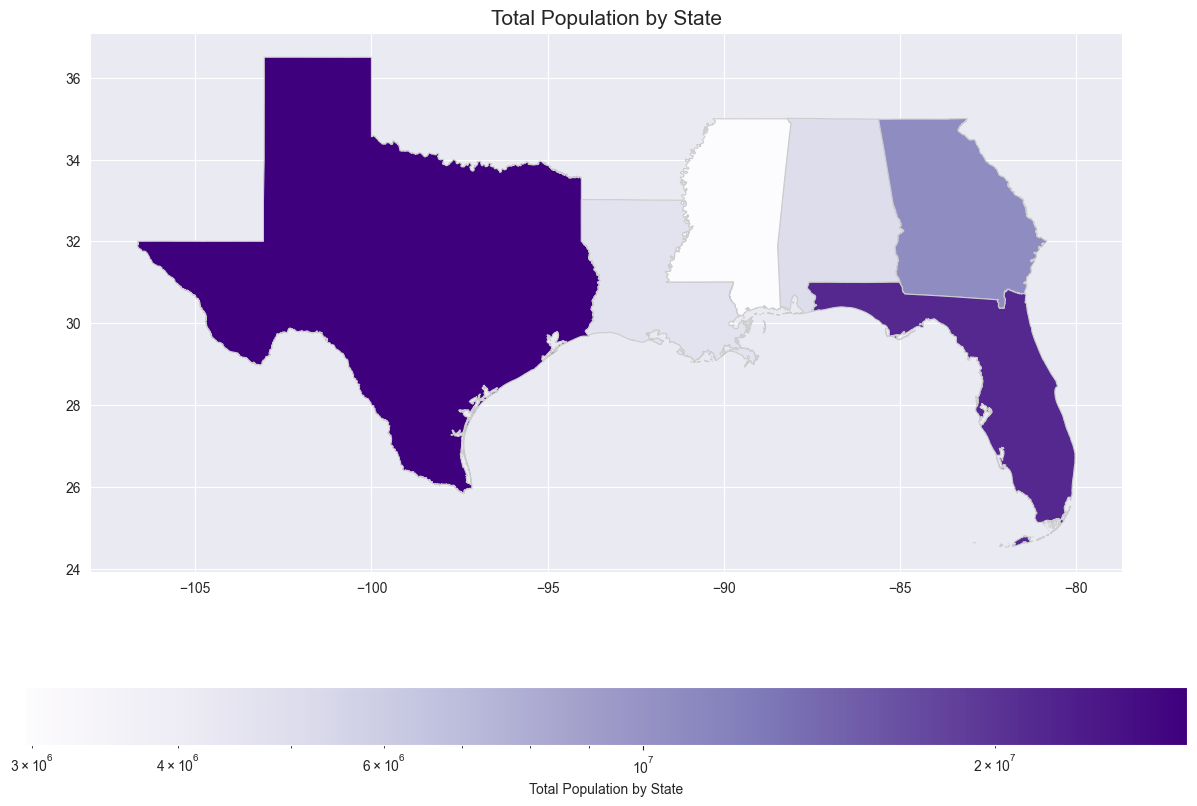

In [19]:
# Load the data (assuming files are in the working directory)
svi_data = pd.read_csv('CIVE202_Project5_SVI_2022_US_county_Wiggins&Anciaux.csv')
states = gpd.read_file("cb_2024_us_state_500k.zip")

# Ensure 'STUSPS' column exists in svi_data for merging
svi_data['STUSPS'] = svi_data['ST_ABBR']

# Aggregate E_TOTPOP from county level to state level
state_pop_data = svi_data.groupby(['STUSPS', 'STATE'])['E_TOTPOP'].sum().reset_index()

# Merge state_pop_data with states GeoDataFrame
complete_data = pd.merge(states, state_pop_data, on='STUSPS', how='left')

# Drop rows with NaN in 'E_TOTPOP' for states not found in SVI data
complete_data.dropna(subset=['E_TOTPOP'], inplace=True)

# Plotting the state populations
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Plot states, colored by E_TOTPOP
complete_data.plot(column='E_TOTPOP',
                   cmap='Purples', 
                   linewidth=0.8,
                   ax=ax,
                   edgecolor='0.8',
                   legend=True,
                   legend_kwds={'label': "Total Population by State",
                                'orientation': "horizontal"},
                   norm=mpc.LogNorm()) # Use LogNorm for better visualization of varying populations

ax.set_title('Total Population by State', fontsize=15)



Text(0.5, 1.0, 'Total Population 65 and Older by State')

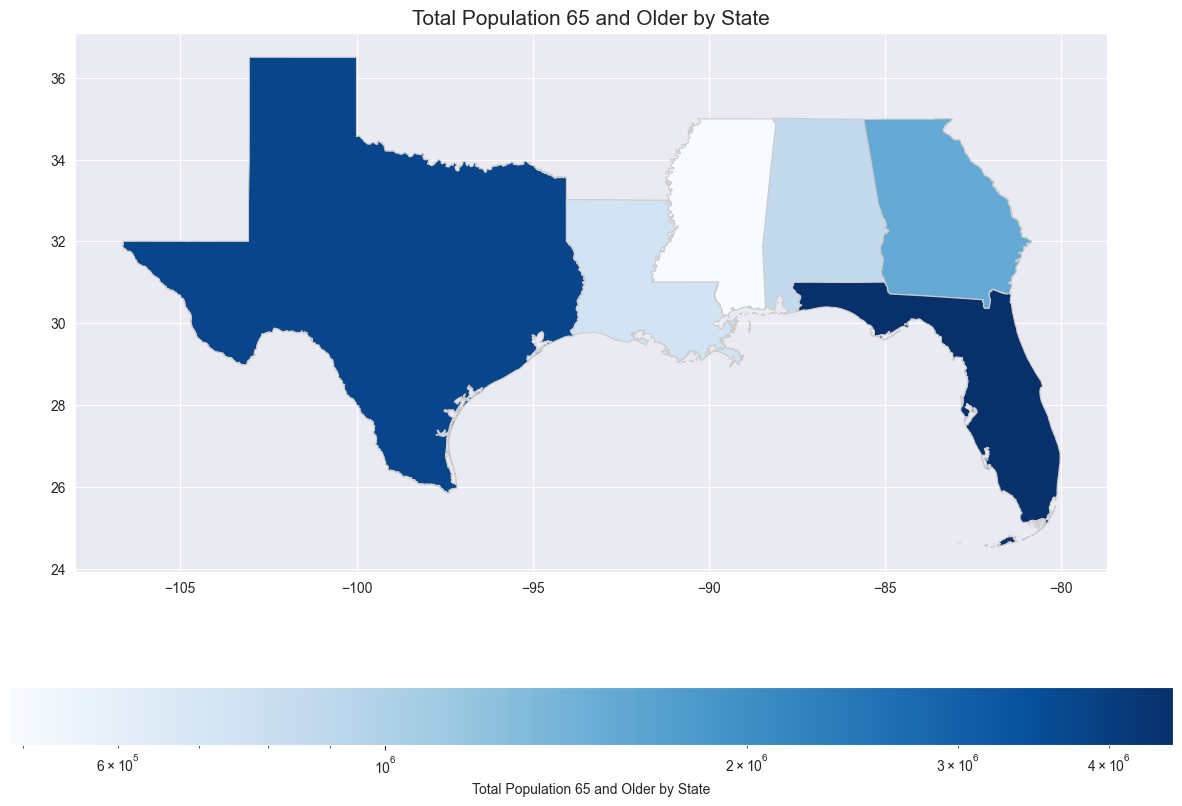

In [21]:


# Aggregate E_TOTPOP from county level to state level
state_pop_data = svi_data.groupby(['STUSPS', 'STATE'])['E_AGE65'].sum().reset_index()

# Merge state_pop_data with states GeoDataFrame
complete_data = pd.merge(states, state_pop_data, on='STUSPS', how='left')

# Drop rows with NaN in 'E_TOTPOP' for states not found in SVI data
complete_data.dropna(subset=['E_AGE65'], inplace=True)

# Plotting the state populations
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Plot states, colored by E_TOTPOP
complete_data.plot(column='E_AGE65',
                   cmap='Blues', 
                   linewidth=0.8,
                   ax=ax,
                   edgecolor='0.8',
                   legend=True,
                   legend_kwds={'label': "Total Population 65 and Older by State",
                                'orientation': "horizontal"},
                   norm=mpc.LogNorm()) # Use LogNorm for better visualization of varying populations

ax.set_title('Total Population 65 and Older by State', fontsize=15)


Text(0.5, 1.0, 'Total Uninsured Population by State')

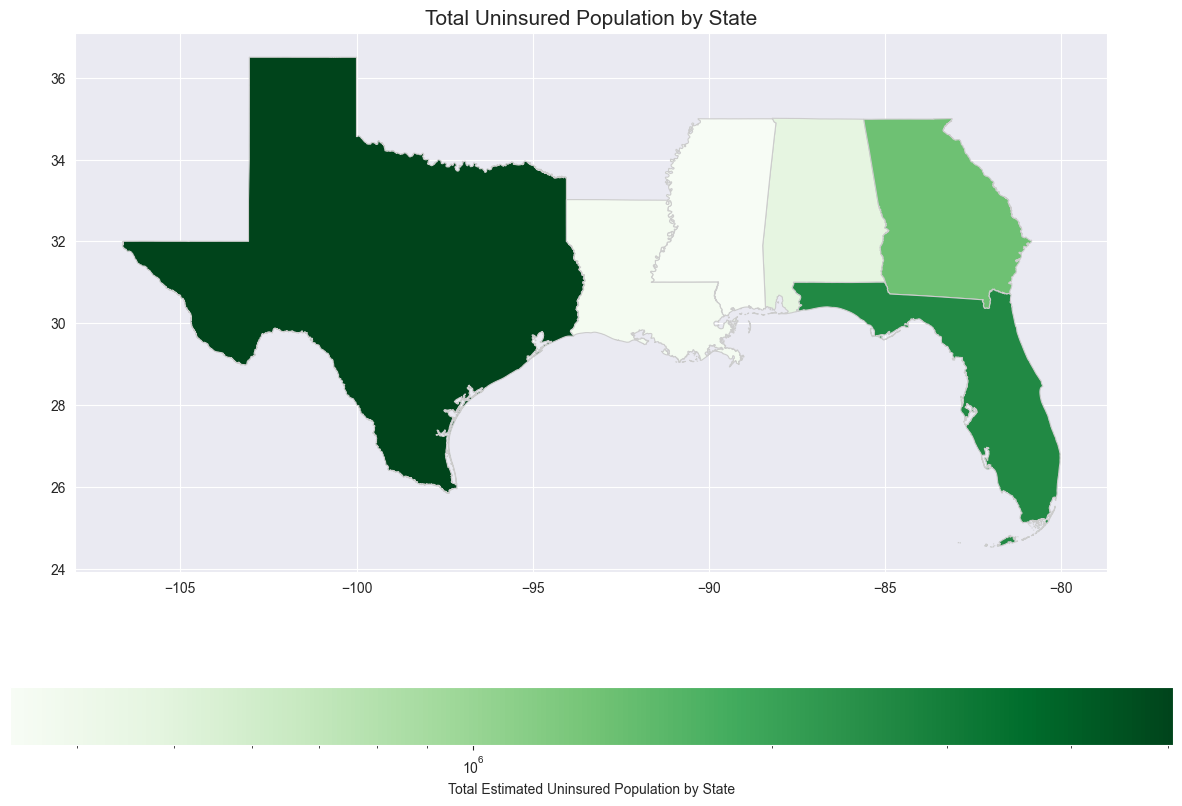

In [27]:


# Aggregate E_TOTPOP from county level to state level
state_pop_data = svi_data.groupby(['STUSPS', 'STATE'])['E_UNINSUR'].sum().reset_index()

# Merge state_pop_data with states GeoDataFrame
complete_data = pd.merge(states, state_pop_data, on='STUSPS', how='left')

# Drop rows with NaN in 'E_TOTPOP' for states not found in SVI data
complete_data.dropna(subset=['E_UNINSUR'], inplace=True)

# Plotting the state populations
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Plot states, colored by E_TOTPOP
complete_data.plot(column='E_UNINSUR',
                   cmap='Greens', 
                   linewidth=0.8,
                   ax=ax,
                   edgecolor='0.8',
                   legend=True,
                   legend_kwds={'label': "Total Estimated Uninsured Population by State",
                                'orientation': "horizontal"},
                   norm=mpc.LogNorm()) # Use LogNorm for better visualization of varying populations

ax.set_title('Total Uninsured Population by State', fontsize=15)